Part 1: Data Understanding, Exploratory Data Analysis (EDA), 
Data Quality Assessment and Data Preprocessing (30 Marks) 

First, load the library

In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import Perceptron

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    multilabel_confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error, 
    root_mean_squared_error, 
    r2_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.feature_selection import f_classif

import tensorflow as tf
import tensorflow.keras.backend as K


Read the dataset

In [2]:
# Read the dataset
df = pd.read_csv("../data/NZ_LUCAS_SMAP_NIWA.csv")

inspect the dataset using descriptive analysis

In [3]:
# Display first 5 rows
print(df.head())

# Check dataset shape
print("Shape:", df.shape)

# Check column names
print("Columns:", df.columns)

# Check for missing values
print(df.isnull().sum())

    latitude   longitude  elevation_m  slope_deg  aspect_deg  \
0 -42.130978  171.117262    97.315825  15.660394  335.473600   
1 -34.640714  172.154664   148.801024   7.974421   38.849851   
2 -37.484079  177.109116   888.809683   9.953119  200.974535   
3 -39.217440  170.420057   394.131619   6.907954   34.959548   
4 -44.971758  177.305446   719.187523   4.219457  205.925811   

   topographic_wetness_index  terrain_ruggedness_index  annual_rainfall_mm  \
0                   7.508100                  7.365608          807.582011   
1                   7.326739                  5.683267         1179.458440   
2                  11.180950                  2.654730          943.442971   
3                   5.846627                  4.005192         1155.294725   
4                   7.425487                  9.832291         1286.631423   

   annual_temperature_c  summer_temperature_c  ...  cation_exchange_capacity  \
0              9.679469             17.235948  ...                

The dataset has 5000 rows and 37 columns. We can see that there is a column named "36" probably a typo as there are no value there so I will not include this column in my analysis from now on. Overall we will have 500 rows and 36 columns. 

Then we will check the data type of the column. 

In [4]:
df.drop(columns=['36']).info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 36 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   latitude                         5000 non-null   float64
 1   longitude                        5000 non-null   float64
 2   elevation_m                      5000 non-null   float64
 3   slope_deg                        5000 non-null   float64
 4   aspect_deg                       5000 non-null   float64
 5   topographic_wetness_index        5000 non-null   float64
 6   terrain_ruggedness_index         5000 non-null   float64
 7   annual_rainfall_mm               5000 non-null   float64
 8   annual_temperature_c             5000 non-null   float64
 9   summer_temperature_c             5000 non-null   float64
 10  winter_temperature_c             5000 non-null   float64
 11  solar_radiation_mj               5000 non-null   float64
 12  potential_evapotranspiration_mm

So all the attributes are float or interger, therefore they are OK for my regression analysis. 

We look at some discriptive analysis of the attributes 

In [5]:
df.drop(columns=['36']).describe()

,latitude,longitude,elevation_m,slope_deg,aspect_deg,topographic_wetness_index,terrain_ruggedness_index,annual_rainfall_mm,annual_temperature_c,summer_temperature_c,...,exchangeable_potassium_mgkg,cation_exchange_capacity,ndvi_mean,evi_mean,ndwi_mean,soil_moisture_pct,soil_quality_index,climate_stress_index,erosion_risk_index,soil_organic_carbon_target
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,-40.541184,172.389333,504.696286,11.995591,178.768030,7.988307,5.008502,1208.560445,11.978216,18.007048,...,180.538182,17.980862,0.618753,0.496562,0.248782,32.113719,71.017943,20.755863,30.040320,63.027099
std,3.765237,3.713015,354.602398,8.321450,103.668752,2.005968,1.979305,392.354324,2.964821,3.128551,...,61.225668,5.997975,0.118695,0.107143,0.145561,9.789973,9.177922,10.982710,16.380964,9.645272
min,-46.999849,166.000687,3.386511,0.033139,0.001993,-0.372295,-1.393806,400.000000,4.000000,7.425280,...,20.000000,3.000000,0.166220,0.106668,-0.239785,5.000000,38.841685,0.000000,0.000000,30.289095
25%,-43.829784,169.212897,245.034151,5.740084,88.885504,6.620432,3.630864,927.915620,9.928302,15.903511,...,137.786792,13.816697,0.538136,0.422380,0.151661,25.439275,64.815829,12.695840,18.501431,56.410138
50%,-40.499888,172.317630,423.162023,10.117302,179.714007,7.959823,4.986927,1206.284688,11.959494,18.018449,...,181.293576,17.901570,0.619458,0.496783,0.248332,31.898949,70.861879,20.021261,28.710494,62.974905
75%,-37.274689,175.533831,679.063317,16.223400,268.169344,9.330974,6.375344,1478.904594,13.985086,20.048785,...,222.464746,22.209178,0.698464,0.569793,0.343520,38.597556,77.252864,28.520322,40.073747,69.386694
max,-34.003670,178.993568,2418.439425,45.000000,359.924174,16.597715,11.674764,2588.146732,20.000000,27.897761,...,385.738197,39.411933,0.950000,0.862023,0.800000,67.233048,100.000000,65.018641,100.000000,101.456979


We also look at the distribution of the columns 

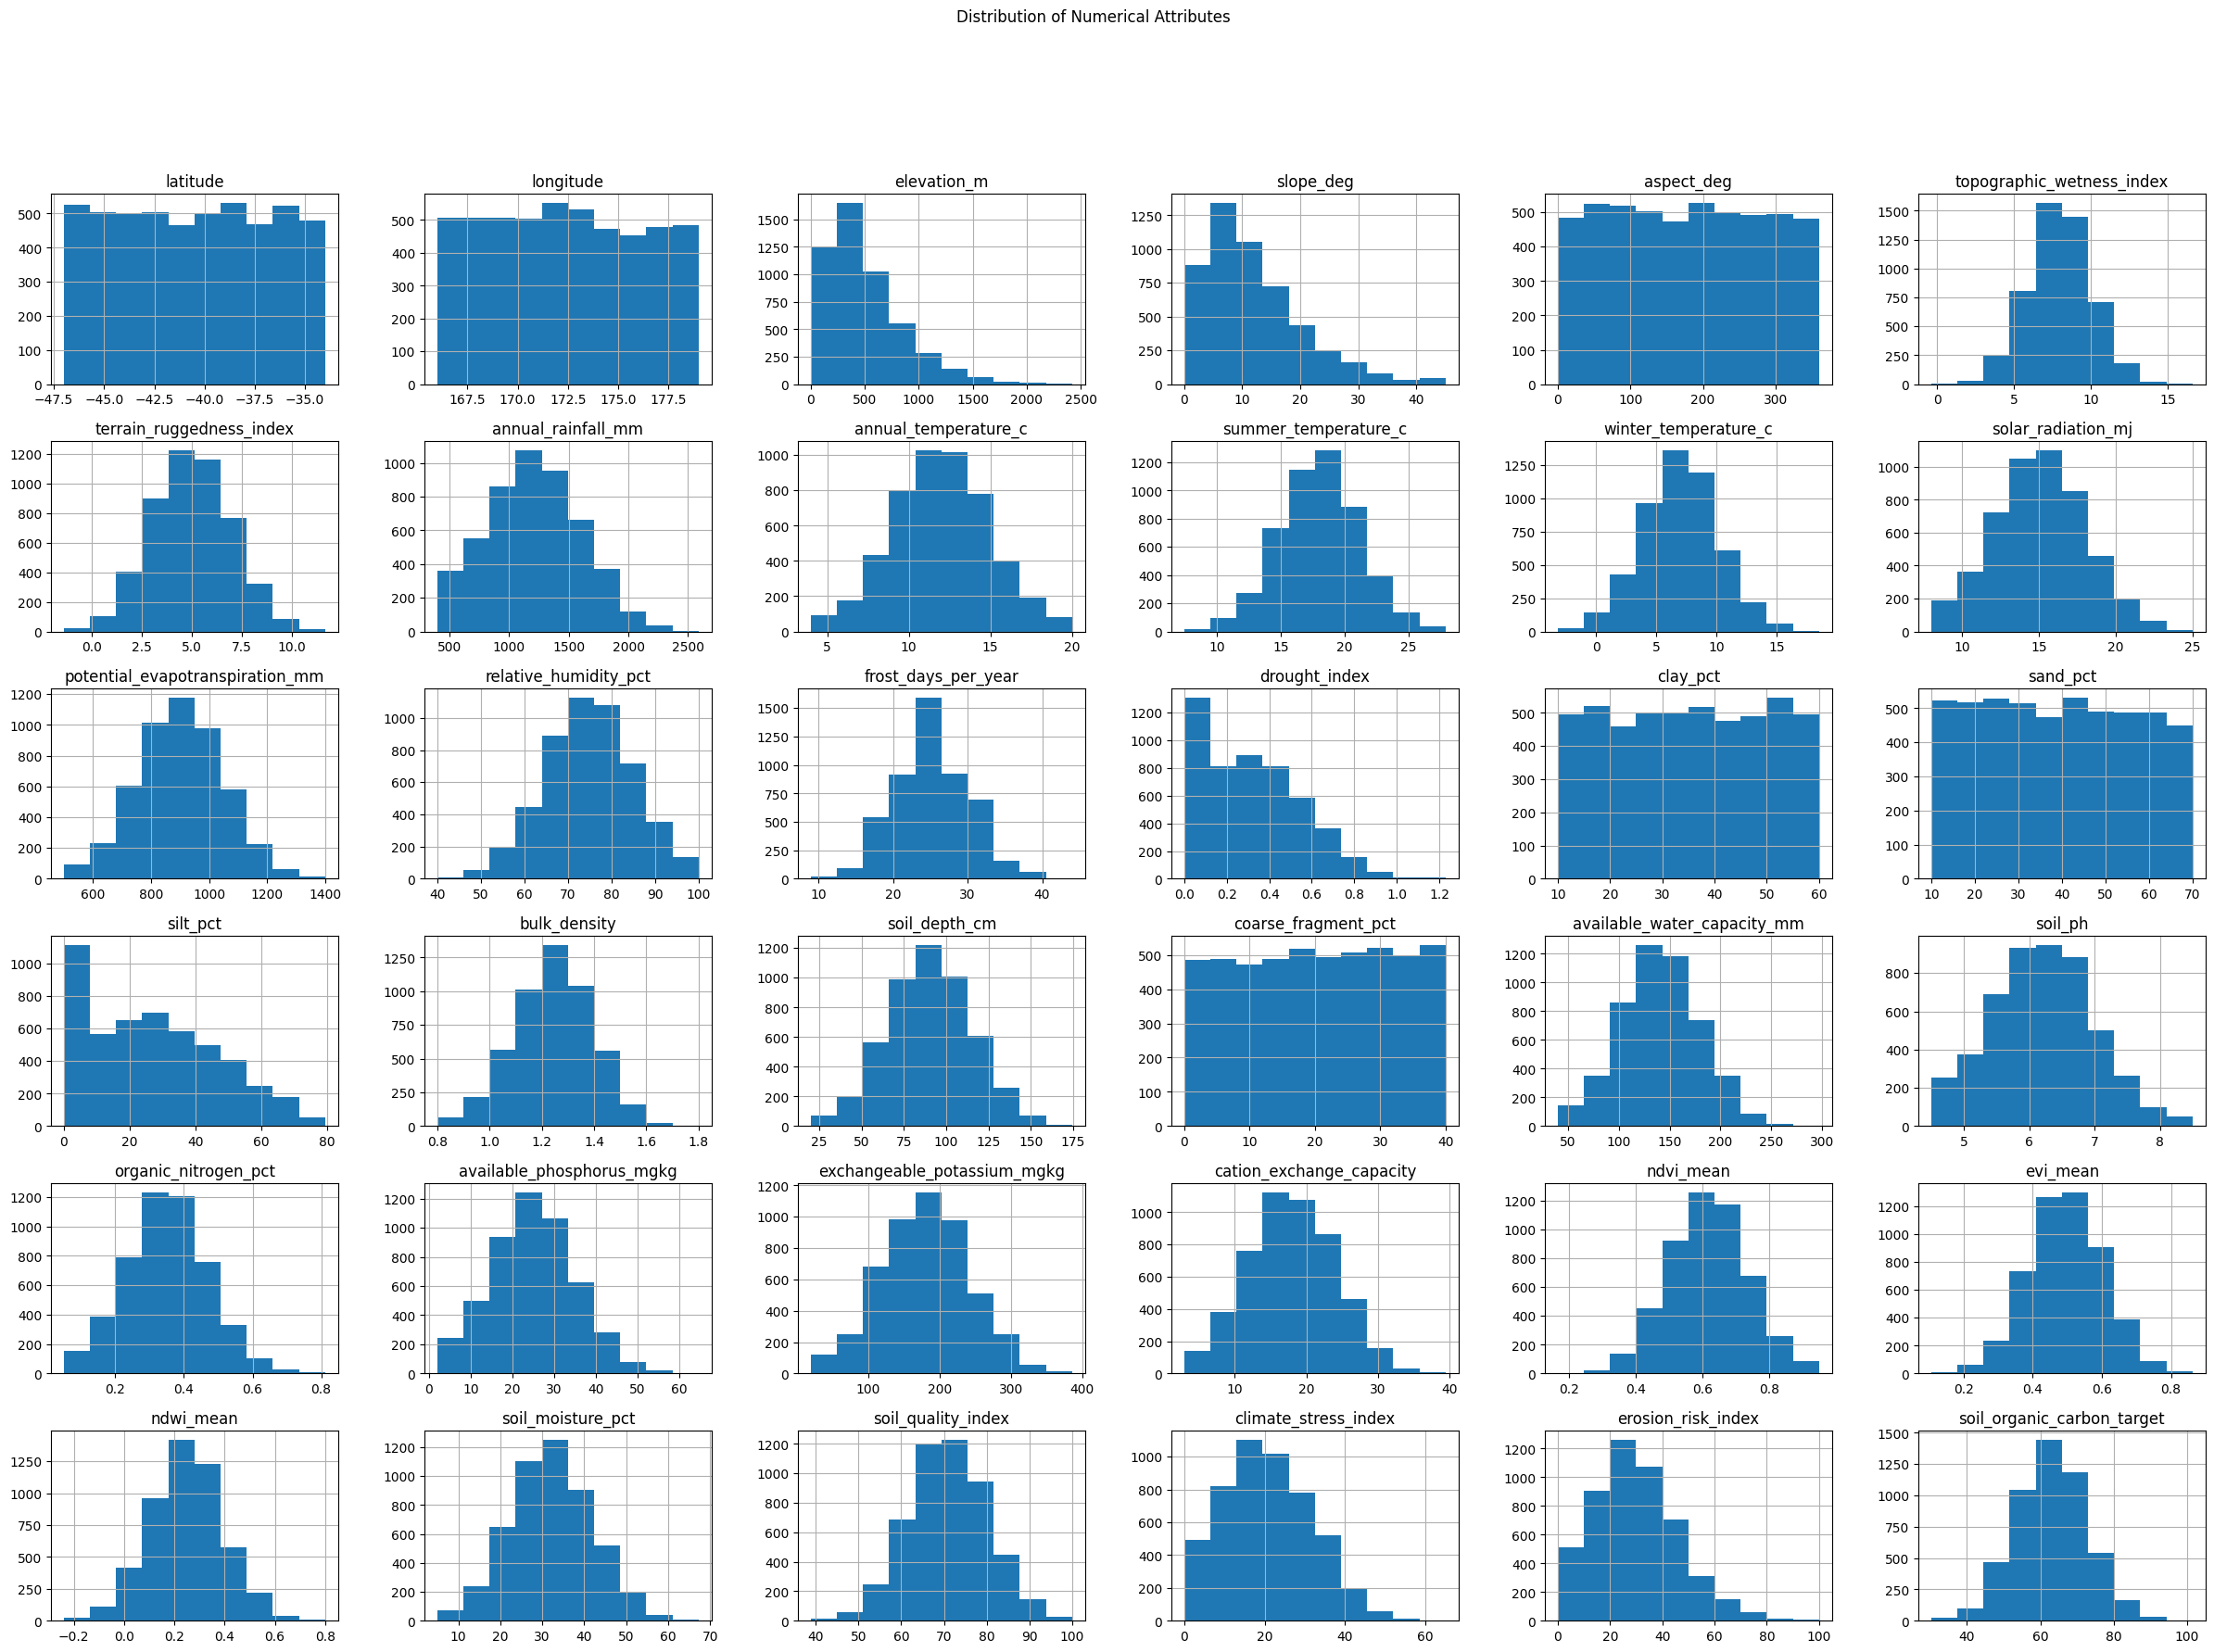

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
df.drop(columns=['36']).hist(figsize=(30,20), bins=10)

plt.suptitle("Distribution of Numerical Attributes")
plt.show()

Visualize the coorelation of the columns

                                 latitude  longitude  elevation_m  slope_deg  \
latitude                         1.000000  -0.007017     0.009618  -0.012696   
longitude                       -0.007017   1.000000    -0.000917  -0.006875   
elevation_m                      0.009618  -0.000917     1.000000   0.003947   
slope_deg                       -0.012696  -0.006875     0.003947   1.000000   
aspect_deg                       0.009606   0.027185    -0.018742  -0.016304   
topographic_wetness_index        0.035214  -0.004480    -0.014719   0.004422   
terrain_ruggedness_index         0.010399   0.009148    -0.027970  -0.021542   
annual_rainfall_mm              -0.006504   0.012395    -0.024788  -0.012274   
annual_temperature_c             0.001136  -0.032947    -0.007204  -0.014971   
summer_temperature_c            -0.000262  -0.026475    -0.001676  -0.019784   
winter_temperature_c            -0.003122  -0.026414    -0.006132  -0.007631   
solar_radiation_mj              -0.00842

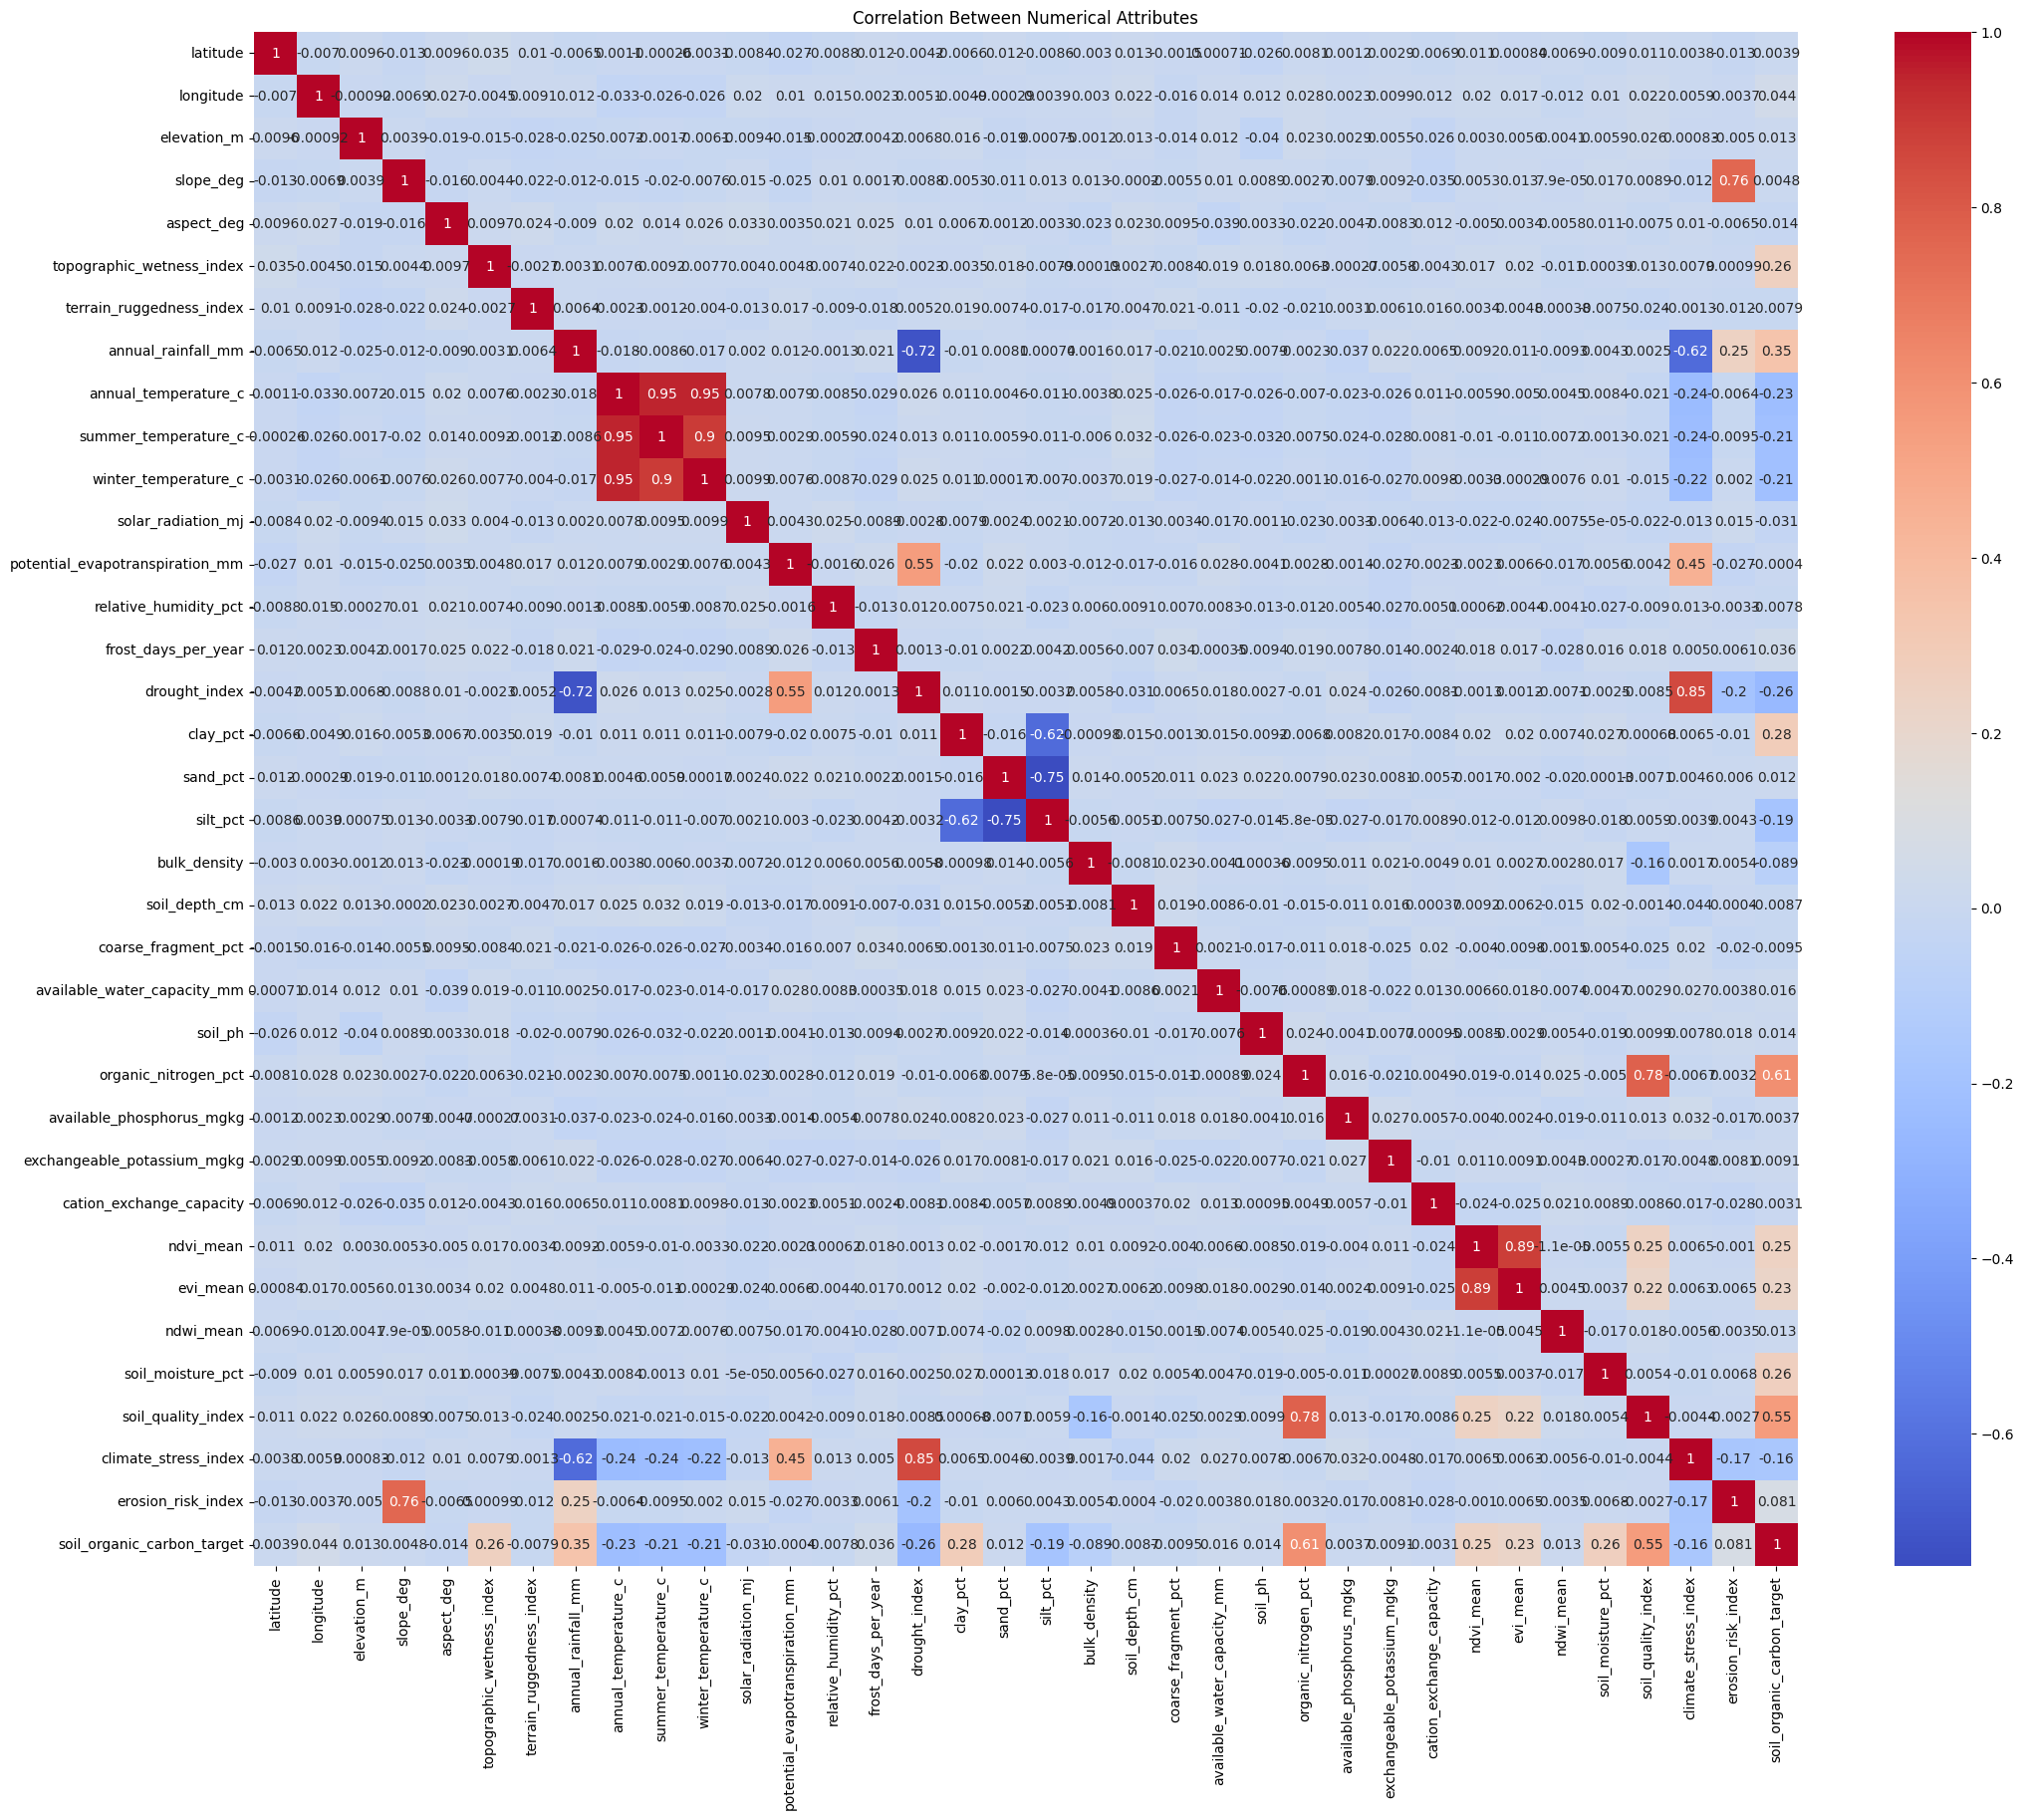

In [7]:

correlation_matrix = df.drop(columns=['36']).corr()

# Display
print(correlation_matrix)

# Heatmap visualization
plt.figure(figsize=(25, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Between Numerical Attributes')
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()



From the coorelation of soil_organic_carbon_target with other attributes as below: 

soil_organic_carbon_target  
latitude                                           0.003906  
longitude                                          0.043984  
elevation_m                                        0.012888  
slope_deg                                          0.004802  
aspect_deg                                        -0.013593  
topographic_wetness_index                          0.259220  
terrain_ruggedness_index                          -0.007854  
annual_rainfall_mm                                 0.348765  
annual_temperature_c                              -0.225865  
summer_temperature_c                              -0.210951  
winter_temperature_c                              -0.212998  
solar_radiation_mj                                -0.030879  
potential_evapotranspiration_mm                   -0.000404  
relative_humidity_pct                             -0.007808  
frost_days_per_year                                0.035935  
drought_index                                     -0.256624  
clay_pct                                           0.283623  
sand_pct                                           0.012057  
silt_pct                                          -0.188958  
bulk_density                                      -0.088608  
soil_depth_cm                                     -0.008693  
coarse_fragment_pct                               -0.009517  
available_water_capacity_mm                        0.015788  
soil_ph                                            0.013597  
organic_nitrogen_pct                               0.606452  
available_phosphorus_mgkg                          0.003675  
exchangeable_potassium_mgkg                        0.009128  
cation_exchange_capacity                          -0.003067  
ndvi_mean                                          0.245269  
evi_mean                                           0.227089  
ndwi_mean                                          0.013016  
soil_moisture_pct                                  0.264877  
soil_quality_index                                 0.553208  
climate_stress_index                              -0.164292  
erosion_risk_index                                 0.081103  
soil_organic_carbon_target                         1.000000 


We can see that the following attributes might be the most important parameters: organic_nitrogen_pct
soil_quality_index
annual_rainfall_mm
clay_pct
soil_moisture_pct
topographic_wetness_index
ndvi_mean
evi_mean
erosion_risk_index
and bulk_density
climate_stress_index
silt_pct
summer_temperature_c
winter_temperature_c
annual_temperature_c
drought_index
